# BTC/USDT — SMA Crossover Backtest: 1H vs 4H Timeframe Comparison

**Goal:** Compare the same SMA crossover strategy across 1-hour and 4-hour candlesticks
to understand how timeframe choice affects profitability, drawdown, and trade frequency.

## Methodology
- **Signal:** Fast SMA crosses above slow SMA → long BTC. Fast crosses below slow → exit to cash.
- **Timeframes:** 1H (raw from yfinance) and 4H (resampled from 1H).
- **Periods:** Defined in real-time hours, then converted to bar counts per timeframe so
  every cell in the 1H heatmap corresponds to an economically equivalent cell in the 4H heatmap.
- **Data window:** ~730 days of hourly data (yfinance maximum).
- **Fees:** 0.1% per trade · $10,000 starting capital.

## Outputs saved to `images/sma-backtest/`
| File | Contents |
|------|----------|
| `return_comparison.png` | Side-by-side return heatmaps (1H vs 4H) |
| `drawdown_comparison.png` | Side-by-side max drawdown heatmaps |
| `sharpe_comparison.png` | Side-by-side Sharpe ratio heatmaps |
| `trades_comparison.png` | Side-by-side trade count heatmaps |
| `timeframe_diff.png` | Delta heatmaps: 4H minus 1H |
| `equity_curves.png` | Top 3 equity curves per timeframe |

In [1]:
import os, time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import yfinance as yf
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')

IMG_DIR = 'images/sma-backtest'
os.makedirs(IMG_DIR, exist_ok=True)
print(f'Libraries loaded.')
print(f'Images will be saved to: {os.path.abspath(IMG_DIR)}')

Libraries loaded.
Images will be saved to: D:\Will\Learning\AI\Notebooks\images\sma-backtest


In [2]:
def fetch_btc_1h():
    raw = yf.Ticker('BTC-USD').history(period='730d', interval='1h')
    raw = raw[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
    raw.columns = ['open', 'high', 'low', 'close', 'volume']
    # Strip timezone from yfinance UTC index
    if raw.index.tz is not None:
        raw.index = raw.index.tz_convert(None)
    raw.index.name = 'date'
    return raw.sort_index().dropna()

print('Fetching 1H BTC-USD data (~730 days)...')
df_1h = fetch_btc_1h()

# Resample 1H → 4H (OHLCV aggregation)
df_4h = df_1h.resample('4h').agg({
    'open': 'first', 'high': 'max', 'low': 'min',
    'close': 'last', 'volume': 'sum'
}).dropna()

price_1h = df_1h['close']
price_4h = df_4h['close']

print(f'1H: {len(df_1h):,} bars  |  {df_1h.index[0].date()} → {df_1h.index[-1].date()}')
print(f'4H: {len(df_4h):,} bars  |  {df_4h.index[0].date()} → {df_4h.index[-1].date()}')
df_1h.tail(3)

Fetching 1H BTC-USD data (~730 days)...
1H: 17,470 bars  |  2024-05-02 → 2026-05-01
4H: 4,370 bars  |  2024-05-02 → 2026-05-01


,open,high,low,close,volume
date,,,,,
2026-05-01 03:00:00,76551.992188,77406.789062,76523.203125,77091.843750,1498173440
2026-05-01 04:00:00,77109.726562,77175.531250,76946.828125,77004.992188,699543552
2026-05-01 05:00:00,77011.171875,77160.140625,76999.781250,77080.890625,170020864


In [3]:
def backtest_sma_cross(price, fast_p, slow_p, fee=0.001, capital=10_000, bars_per_year=8760):
    fast_ma = price.rolling(fast_p).mean()
    slow_ma = price.rolling(slow_p).mean()
    valid = fast_ma.notna() & slow_ma.notna()
    if valid.sum() < 10:
        return None

    p   = price[valid].values
    f   = fast_ma[valid].values
    s   = slow_ma[valid].values
    idx = price[valid].index

    pos = (f > s).astype(int)
    chg = np.diff(pos, prepend=pos[0])

    cash = float(capital); btc = 0.0
    pv = np.empty(len(p)); n_trades = 0

    for i in range(len(p)):
        if chg[i] == 1 and cash > 0:
            btc = cash * (1 - fee) / p[i]; cash = 0.0; n_trades += 1
        elif chg[i] == -1 and btc > 0:
            cash = btc * p[i] * (1 - fee); btc = 0.0; n_trades += 1
        pv[i] = cash + btc * p[i]

    pv_s  = pd.Series(pv, index=idx)
    final = pv_s.iloc[-1]
    total = (final - capital) / capital * 100

    rf  = (1.04 ** (1 / bars_per_year)) - 1
    dr  = pv_s.pct_change().dropna()
    std = dr.std()
    exc = dr - rf
    sharpe  = (exc.mean() / std) * np.sqrt(bars_per_year) if std > 0 else 0.0
    down    = dr[dr < rf]
    sortino = (exc.mean() / down.std()) * np.sqrt(bars_per_year)               if (len(down) > 1 and down.std() > 0) else 0.0

    roll_max = pv_s.cummax()
    max_dd   = ((pv_s - roll_max) / roll_max * 100).min()

    return {
        'total_return': round(total,   1),
        'max_drawdown': round(max_dd,  1),
        'sharpe':       round(sharpe,  3),
        'sortino':      round(sortino, 3),
        'n_trades':     n_trades,
        'final_value':  round(final,   2),
        'pv':           pv_s,
    }

print('SMA backtest engine ready.')

SMA backtest engine ready.


In [4]:
# Periods defined in hours → converted to bars per timeframe so the
# same economic window is tested on both 1H and 4H charts.
FAST_HOURS = [12, 24, 48, 120, 240]    # 12h / 1d / 2d / 5d / 10d
SLOW_HOURS = [480, 720, 1440, 2160]    # 20d / 30d / 60d / 90d

def h2b(hours, tf_hours):
    return max(2, round(hours / tf_hours))

FAST_1H = [h2b(h, 1) for h in FAST_HOURS]
SLOW_1H = [h2b(h, 1) for h in SLOW_HOURS]
FAST_4H = [h2b(h, 4) for h in FAST_HOURS]
SLOW_4H = [h2b(h, 4) for h in SLOW_HOURS]

def fmt_h(h):
    if h < 24:   return f'{h}h'
    if h < 168:  return f'{h // 24}d'
    if h < 720:  return f'{h // 168}w'
    return f'{h // 720}mo'

fast_labels = [fmt_h(h) for h in FAST_HOURS]
slow_labels  = [fmt_h(h) for h in SLOW_HOURS]

print(f'Fast labels : {fast_labels}')
print(f'Slow labels : {slow_labels}')
print()
print(f'{"Period":>6}  {"1H bars":>8}  {"4H bars":>8}')
print('-' * 26)
for h, lbl, b1, b4 in zip(FAST_HOURS, fast_labels, FAST_1H, FAST_4H):
    print(f'{lbl:>6} (fast)  {b1:>6}       {b4:>5}')
for h, lbl, b1, b4 in zip(SLOW_HOURS, slow_labels, SLOW_1H, SLOW_4H):
    print(f'{lbl:>6} (slow)  {b1:>6}       {b4:>5}')
print()
print(f'Grid: {len(fast_labels)} fast x {len(slow_labels)} slow = {len(fast_labels)*len(slow_labels)} combos x 2 TFs = {2*len(fast_labels)*len(slow_labels)} total backtests')

Fast labels : ['12h', '1d', '2d', '5d', '1w']
Slow labels : ['2w', '1mo', '2mo', '3mo']

Period   1H bars   4H bars
--------------------------
   12h (fast)      12           3
    1d (fast)      24           6
    2d (fast)      48          12
    5d (fast)     120          30
    1w (fast)     240          60
    2w (slow)     480         120
   1mo (slow)     720         180
   2mo (slow)    1440         360
   3mo (slow)    2160         540

Grid: 5 fast x 4 slow = 20 combos x 2 TFs = 40 total backtests


In [5]:
BPY_1H = 24 * 365    # bars per year — 1H annualisation factor
BPY_4H =  6 * 365    # bars per year — 4H annualisation factor
CAPITAL = 10_000

def run_grid(price, fast_bars, slow_bars, bpy):
    res = {}
    for fl, fb in zip(fast_labels, fast_bars):
        for sl, sb in zip(slow_labels, slow_bars):
            r = backtest_sma_cross(price, fb, sb, bars_per_year=bpy)
            if r is not None:
                res[(fl, sl)] = r
    return res

print('Running 1H grid...')
t0 = time.time()
res_1h = run_grid(price_1h, FAST_1H, SLOW_1H, BPY_1H)
print(f'  Done: {len(res_1h)} combos in {time.time()-t0:.2f}s')

print('Running 4H grid...')
t0 = time.time()
res_4h = run_grid(price_4h, FAST_4H, SLOW_4H, BPY_4H)
print(f'  Done: {len(res_4h)} combos in {time.time()-t0:.2f}s')

# Buy-and-hold reference over the same window
bh_ret   = (price_1h.iloc[-1] / price_1h.iloc[0] - 1) * 100
bh_pv_1h = pd.Series(CAPITAL * price_1h.values / price_1h.values[0], index=price_1h.index)
bh_pv_4h = pd.Series(CAPITAL * price_4h.values / price_4h.values[0], index=price_4h.index)

today_str    = datetime.today().strftime('%Y-%m-%d')
all_ret_1h   = [r['total_return'] for r in res_1h.values()]
all_ret_4h   = [r['total_return'] for r in res_4h.values()]

print(f'\nBTC B&H over window: {bh_ret:.1f}%')
print(f'1H — Best: {max(all_ret_1h):.1f}%  Median: {np.median(all_ret_1h):.1f}%  Worst: {min(all_ret_1h):.1f}%  Beat B&H: {sum(r>bh_ret for r in all_ret_1h)}/{len(all_ret_1h)}')
print(f'4H — Best: {max(all_ret_4h):.1f}%  Median: {np.median(all_ret_4h):.1f}%  Worst: {min(all_ret_4h):.1f}%  Beat B&H: {sum(r>bh_ret for r in all_ret_4h)}/{len(all_ret_4h)}')

Running 1H grid...
  Done: 20 combos in 0.15s
Running 4H grid...
  Done: 20 combos in 0.05s

BTC B&H over window: 33.5%
1H — Best: 63.9%  Median: 29.4%  Worst: -8.5%  Beat B&H: 9/20
4H — Best: 65.3%  Median: 32.5%  Worst: -9.3%  Beat B&H: 9/20


In [6]:
def build_hm(res, metric):
    hm = pd.DataFrame(np.nan, index=fast_labels, columns=slow_labels)
    for (fl, sl), r in res.items():
        hm.loc[fl, sl] = r[metric]
    return hm

ret_1h = build_hm(res_1h, 'total_return');  ret_4h = build_hm(res_4h, 'total_return')
dd_1h  = build_hm(res_1h, 'max_drawdown');  dd_4h  = build_hm(res_4h, 'max_drawdown')
sh_1h  = build_hm(res_1h, 'sharpe');        sh_4h  = build_hm(res_4h, 'sharpe')
tr_1h  = build_hm(res_1h, 'n_trades');      tr_4h  = build_hm(res_4h, 'n_trades')
print('Pivot matrices built.')

Pivot matrices built.


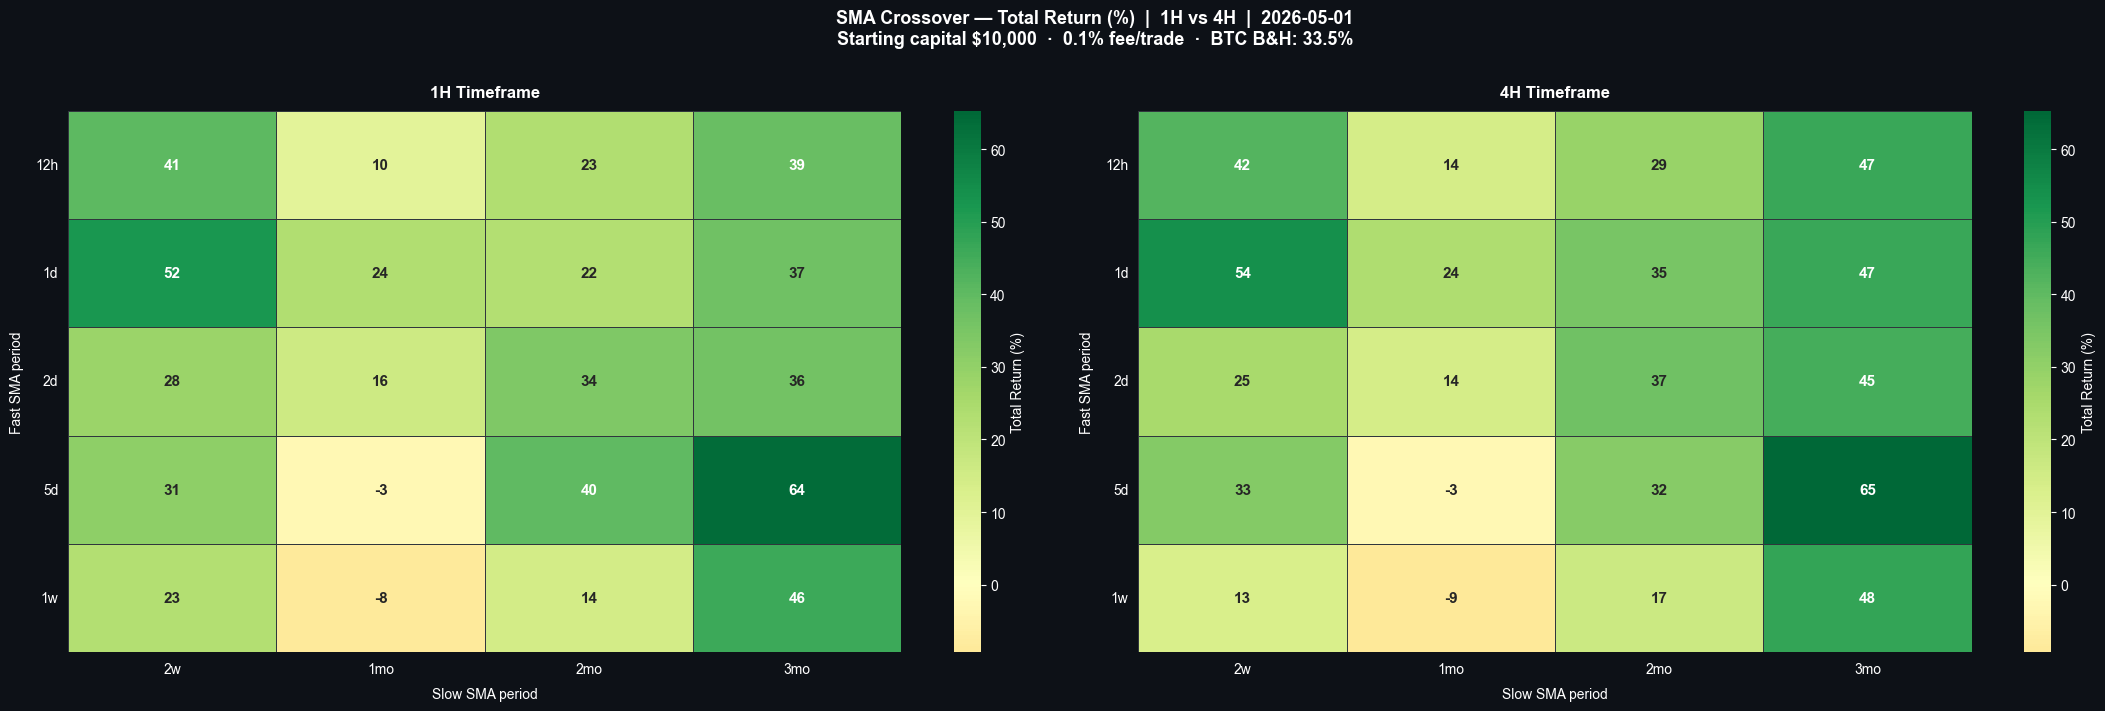

In [7]:
def _style_ax(ax, title):
    ax.set_facecolor('#161b22')
    ax.set_title(title, color='white', fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Slow SMA period', color='white', fontsize=10, labelpad=8)
    ax.set_ylabel('Fast SMA period', color='white', fontsize=10, labelpad=8)
    ax.tick_params(colors='white', labelsize=10)
    plt.setp(ax.get_xticklabels(), rotation=0, ha='center', color='white')
    plt.setp(ax.get_yticklabels(), rotation=0, color='white')
    for spine in ax.spines.values():
        spine.set_color('#30363d')

# Shared colour scale so both TFs are directly comparable
VMIN_R = min(float(ret_1h.values.min()), float(ret_4h.values.min()))
VMAX_R = max(float(ret_1h.values.max()), float(ret_4h.values.max()))

fig, axes = plt.subplots(1, 2, figsize=(22, 7), facecolor='#0d1117')
fig.suptitle(
    f'SMA Crossover — Total Return (%)  |  1H vs 4H  |  {today_str}\n'
    f'Starting capital $10,000  ·  0.1% fee/trade  ·  BTC B&H: {bh_ret:.1f}%',
    color='white', fontsize=13, fontweight='bold', y=1.01
)
for ax, hm, tf in zip(axes, [ret_1h, ret_4h], ['1H', '4H']):
    sns.heatmap(hm.astype(float), annot=True, fmt='.0f',
                cmap='RdYlGn', center=0, vmin=VMIN_R, vmax=VMAX_R,
                ax=ax, linewidths=0.5, linecolor='#30363d',
                annot_kws={'size': 11, 'weight': 'bold'},
                cbar_kws={'label': 'Total Return (%)'})
    _style_ax(ax, f'{tf} Timeframe')
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/return_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

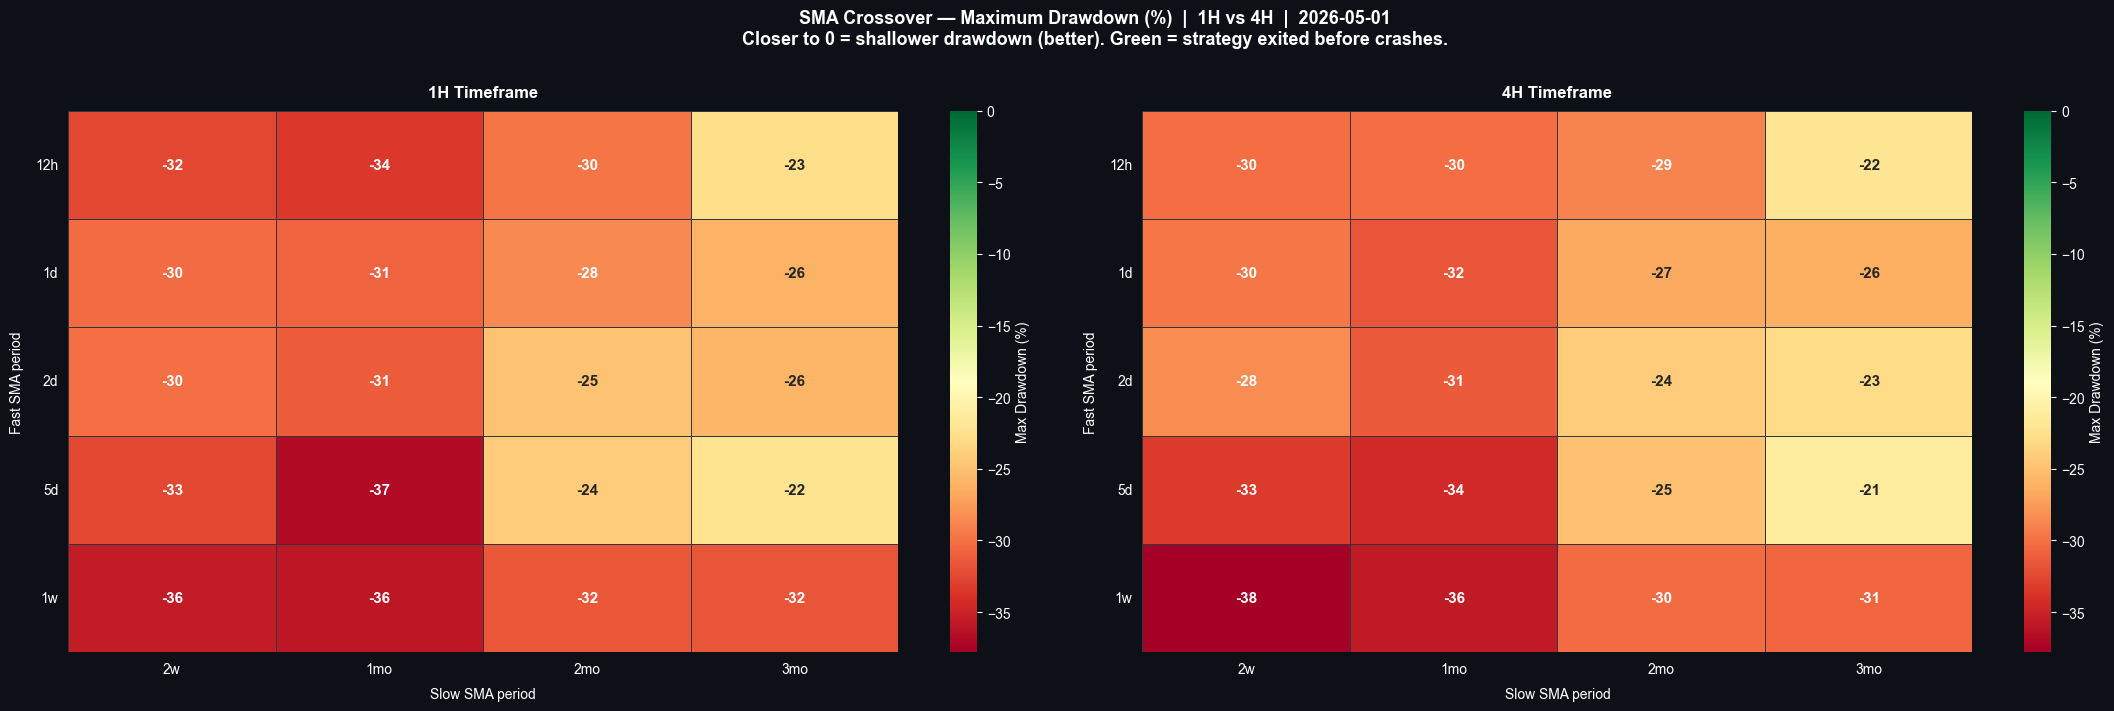

In [8]:
VMIN_D = min(float(dd_1h.values.min()), float(dd_4h.values.min()))

fig, axes = plt.subplots(1, 2, figsize=(22, 7), facecolor='#0d1117')
fig.suptitle(
    f'SMA Crossover — Maximum Drawdown (%)  |  1H vs 4H  |  {today_str}\n'
    f'Closer to 0 = shallower drawdown (better). Green = strategy exited before crashes.',
    color='white', fontsize=13, fontweight='bold', y=1.01
)
for ax, hm, tf in zip(axes, [dd_1h, dd_4h], ['1H', '4H']):
    sns.heatmap(hm.astype(float), annot=True, fmt='.0f',
                cmap='RdYlGn', vmin=VMIN_D, vmax=0,
                ax=ax, linewidths=0.5, linecolor='#30363d',
                annot_kws={'size': 11, 'weight': 'bold'},
                cbar_kws={'label': 'Max Drawdown (%)'})
    _style_ax(ax, f'{tf} Timeframe')
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/drawdown_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

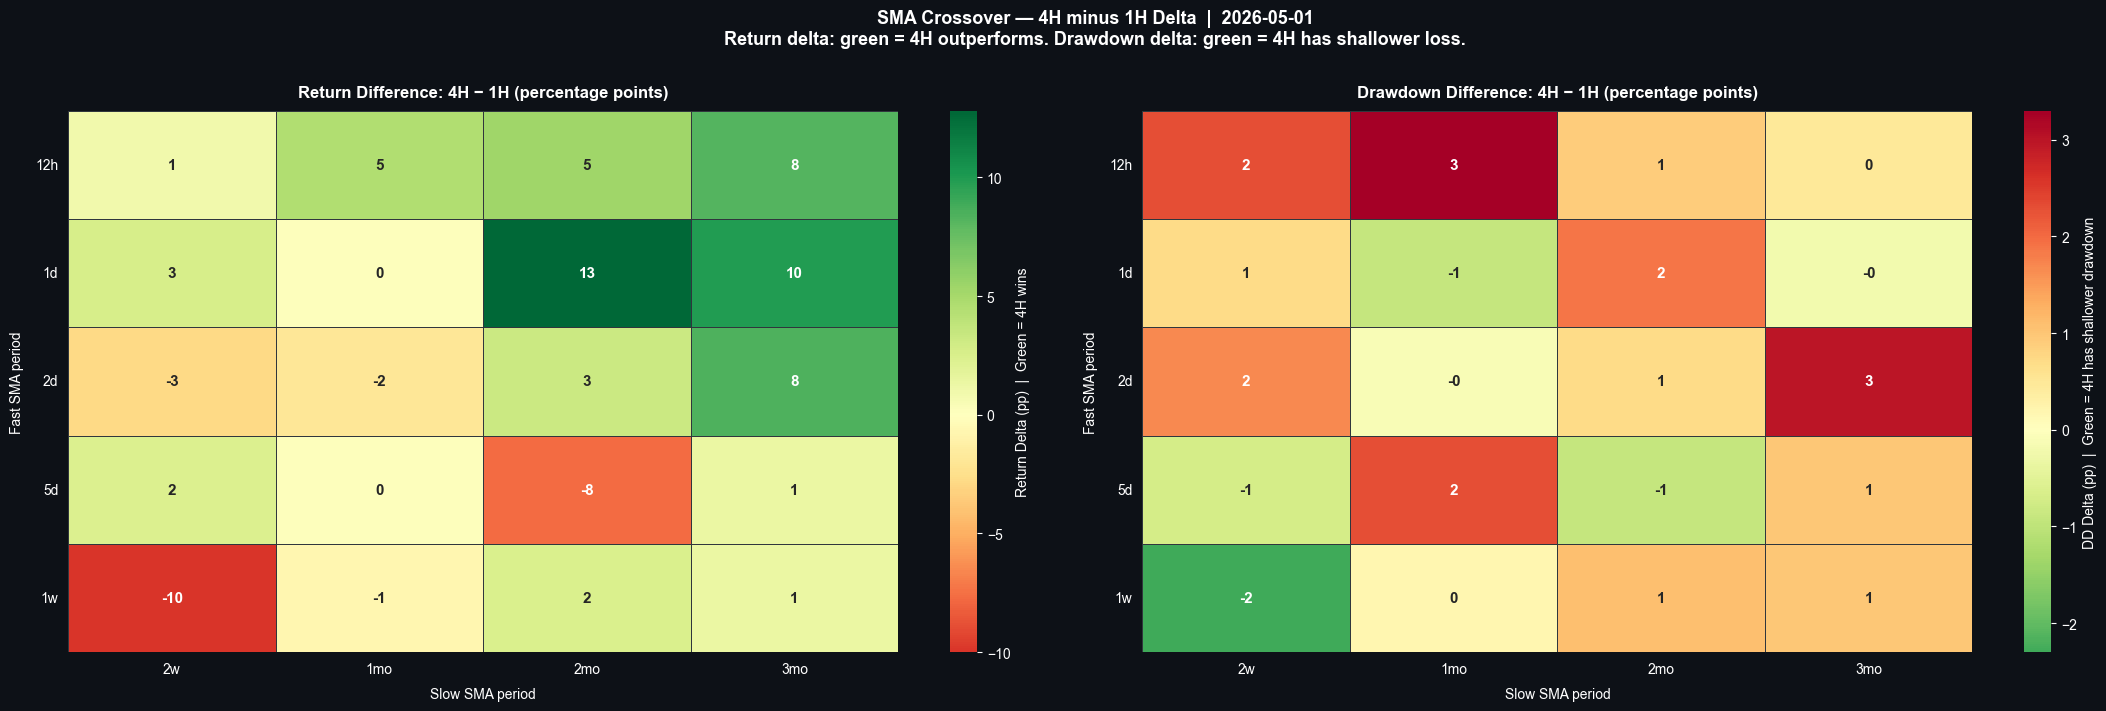

In [9]:
ret_diff = ret_4h.astype(float) - ret_1h.astype(float)   # positive = 4H wins on return
dd_diff  = dd_4h.astype(float)  - dd_1h.astype(float)    # positive = 4H has deeper DD (worse)

fig, axes = plt.subplots(1, 2, figsize=(22, 7), facecolor='#0d1117')
fig.suptitle(
    f'SMA Crossover — 4H minus 1H Delta  |  {today_str}\n'
    f'Return delta: green = 4H outperforms. Drawdown delta: green = 4H has shallower loss.',
    color='white', fontsize=13, fontweight='bold', y=1.01
)

# Return delta (green = 4H better)
sns.heatmap(ret_diff, annot=True, fmt='.0f',
            cmap='RdYlGn', center=0,
            ax=axes[0], linewidths=0.5, linecolor='#30363d',
            annot_kws={'size': 11, 'weight': 'bold'},
            cbar_kws={'label': 'Return Delta (pp)  |  Green = 4H wins'})
_style_ax(axes[0], 'Return Difference: 4H − 1H (percentage points)')

# Drawdown delta (reversed: positive = 4H deeper = worse, so RdYlGn_r)
sns.heatmap(dd_diff, annot=True, fmt='.0f',
            cmap='RdYlGn_r', center=0,
            ax=axes[1], linewidths=0.5, linecolor='#30363d',
            annot_kws={'size': 11, 'weight': 'bold'},
            cbar_kws={'label': 'DD Delta (pp)  |  Green = 4H has shallower drawdown'})
_style_ax(axes[1], 'Drawdown Difference: 4H − 1H (percentage points)')

plt.tight_layout()
plt.savefig(f'{IMG_DIR}/timeframe_diff.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

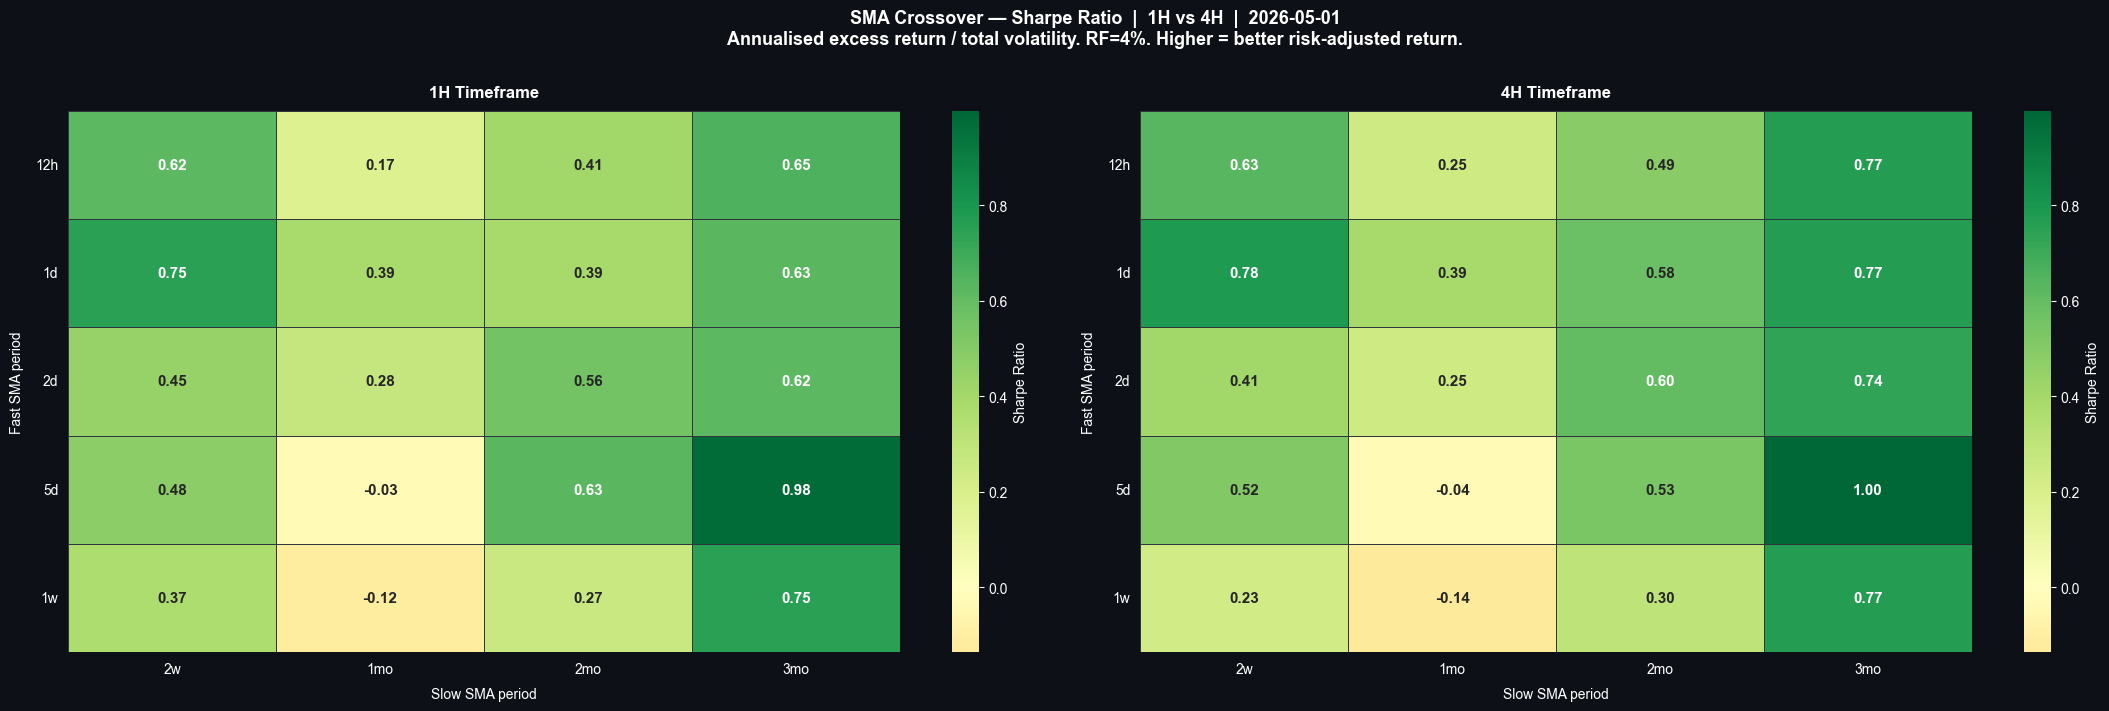

In [10]:
VMIN_S = min(float(sh_1h.values.min()), float(sh_4h.values.min()))
VMAX_S = max(float(sh_1h.values.max()), float(sh_4h.values.max()))

fig, axes = plt.subplots(1, 2, figsize=(22, 7), facecolor='#0d1117')
fig.suptitle(
    f'SMA Crossover — Sharpe Ratio  |  1H vs 4H  |  {today_str}\n'
    f'Annualised excess return / total volatility. RF=4%. Higher = better risk-adjusted return.',
    color='white', fontsize=13, fontweight='bold', y=1.01
)
for ax, hm, tf in zip(axes, [sh_1h, sh_4h], ['1H', '4H']):
    sns.heatmap(hm.astype(float), annot=True, fmt='.2f',
                cmap='RdYlGn', center=0, vmin=VMIN_S, vmax=VMAX_S,
                ax=ax, linewidths=0.5, linecolor='#30363d',
                annot_kws={'size': 11, 'weight': 'bold'},
                cbar_kws={'label': 'Sharpe Ratio'})
    _style_ax(ax, f'{tf} Timeframe')
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/sharpe_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

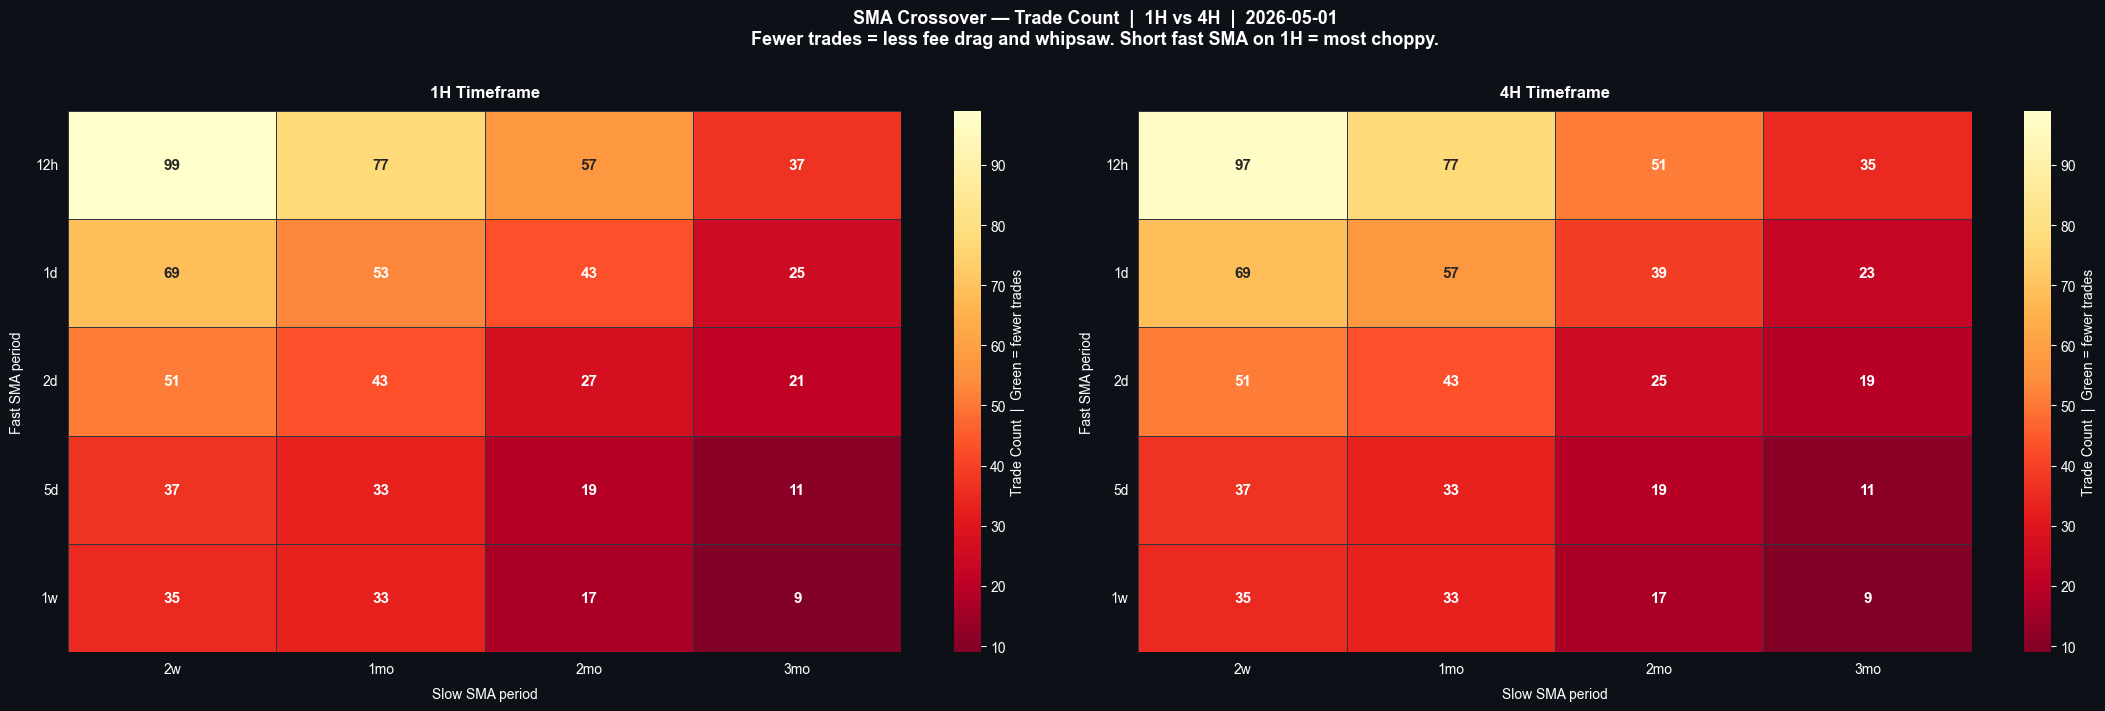

In [11]:
VMIN_T = min(float(tr_1h.values.min()), float(tr_4h.values.min()))
VMAX_T = max(float(tr_1h.values.max()), float(tr_4h.values.max()))

fig, axes = plt.subplots(1, 2, figsize=(22, 7), facecolor='#0d1117')
fig.suptitle(
    f'SMA Crossover — Trade Count  |  1H vs 4H  |  {today_str}\n'
    f'Fewer trades = less fee drag and whipsaw. Short fast SMA on 1H = most choppy.',
    color='white', fontsize=13, fontweight='bold', y=1.01
)
for ax, hm, tf in zip(axes, [tr_1h, tr_4h], ['1H', '4H']):
    sns.heatmap(hm.astype(float), annot=True, fmt='.0f',
                cmap='YlOrRd_r', vmin=VMIN_T, vmax=VMAX_T,
                ax=ax, linewidths=0.5, linecolor='#30363d',
                annot_kws={'size': 11, 'weight': 'bold'},
                cbar_kws={'label': 'Trade Count  |  Green = fewer trades'})
    _style_ax(ax, f'{tf} Timeframe')
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/trades_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

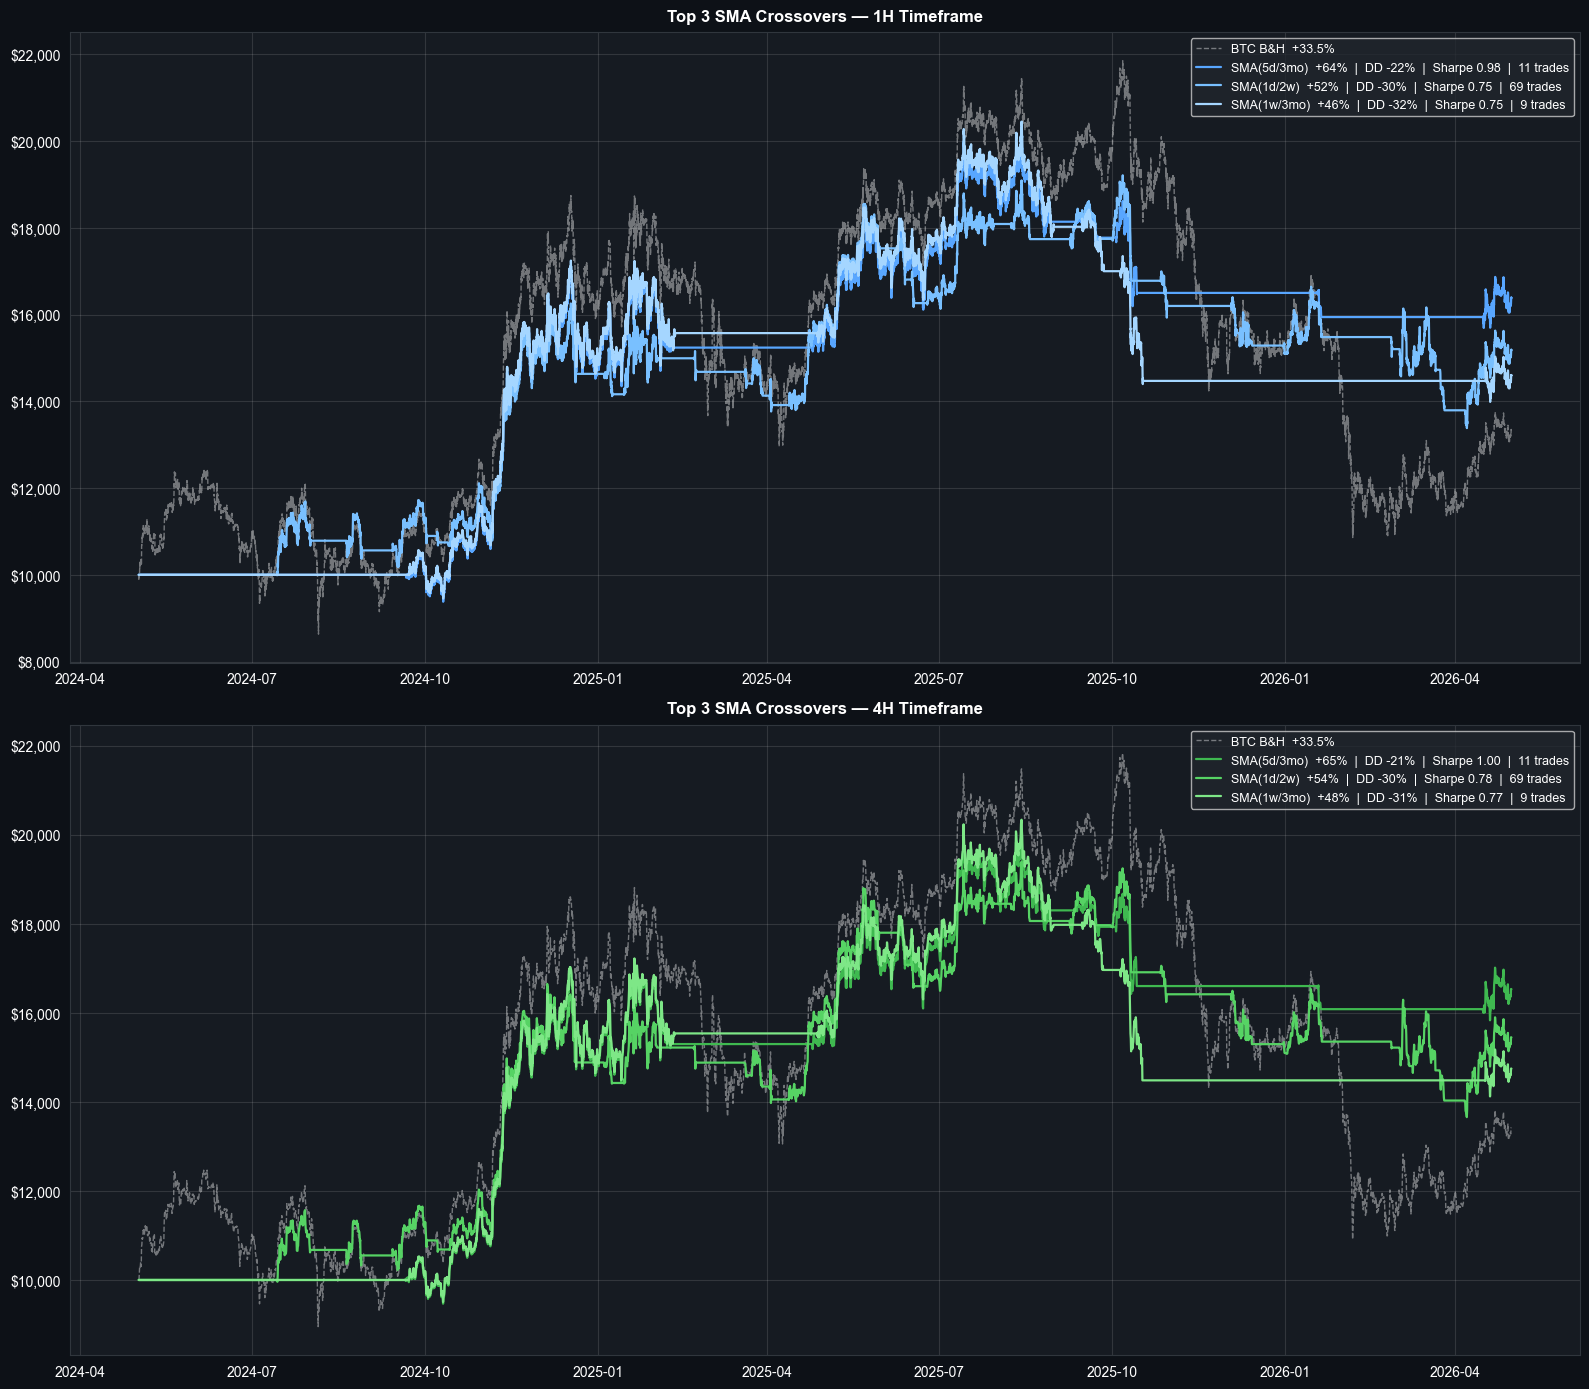

In [12]:
sorted_1h = sorted(res_1h.items(), key=lambda x: x[1]['total_return'], reverse=True)
sorted_4h = sorted(res_4h.items(), key=lambda x: x[1]['total_return'], reverse=True)
top3_1h   = sorted_1h[:3]
top3_4h   = sorted_4h[:3]

C1 = ['#58a6ff', '#79c0ff', '#a5d6ff']
C4 = ['#3fb950', '#56d364', '#7ee787']

fig, axes = plt.subplots(2, 1, figsize=(16, 14), facecolor='#0d1117')

for ax, top3, bh_pv, tf, colors in [
    (axes[0], top3_1h, bh_pv_1h, '1H', C1),
    (axes[1], top3_4h, bh_pv_4h, '4H', C4),
]:
    ax.set_facecolor('#161b22')
    ax.plot(bh_pv.index, bh_pv.values, color='white', lw=1.0, ls='--', alpha=0.4,
            label=f'BTC B&H  {bh_ret:+.1f}%')
    for i, ((fl, sl), r) in enumerate(top3):
        pv_aligned = r['pv'].reindex(bh_pv.index).fillna(CAPITAL)
        ax.plot(pv_aligned.index, pv_aligned.values, color=colors[i], lw=1.6,
                label=f'SMA({fl}/{sl})  {r["total_return"]:+.0f}%  |  '
                      f'DD {r["max_drawdown"]:.0f}%  |  Sharpe {r["sharpe"]:.2f}  |  {r["n_trades"]} trades')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.set_title(f'Top 3 SMA Crossovers — {tf} Timeframe', color='white', fontsize=12,
                 fontweight='bold', pad=8)
    ax.legend(facecolor='#21262d', labelcolor='white', fontsize=9)
    ax.grid(alpha=0.12)
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_color('#30363d')

plt.tight_layout()
plt.savefig(f'{IMG_DIR}/equity_curves.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

In [13]:
print('=' * 68)
print('    SMA CROSSOVER — 1H vs 4H TIMEFRAME COMPARISON SUMMARY')
print('=' * 68)
print(f'  Window:  {df_1h.index[0].date()} → {df_1h.index[-1].date()}')
print(f'  Grid:    {len(fast_labels)} fast x {len(slow_labels)} slow = {len(res_1h)} combos per timeframe')
print(f'  BTC B&H over this window: {bh_ret:.1f}%')
print()

for tf, res, all_ret in [('1H', res_1h, all_ret_1h), ('4H', res_4h, all_ret_4h)]:
    s_r = sorted(res.items(), key=lambda x: x[1]['total_return'], reverse=True)
    bk, br = s_r[0];  wk, wr = s_r[-1]
    best_sh = max(res.items(), key=lambda x: x[1]['sharpe'])
    print(f'  ── {tf} ─────────────────────────────────────────────────')
    print(f'  Median return:  {np.median(all_ret):.1f}%  |  '
          f'Beat B&H: {sum(r > bh_ret for r in all_ret)}/{len(all_ret)}')
    print(f'  Best return:    SMA({bk[0]}/{bk[1]})  {br["total_return"]:+.0f}%  '
          f'DD {br["max_drawdown"]:.0f}%  Sharpe {br["sharpe"]:.2f}  {br["n_trades"]} trades')
    print(f'  Best Sharpe:    SMA({best_sh[0][0]}/{best_sh[0][1]})  '
          f'{best_sh[1]["total_return"]:+.0f}%  Sharpe {best_sh[1]["sharpe"]:.2f}')
    print(f'  Worst return:   SMA({wk[0]}/{wk[1]})  {wr["total_return"]:+.0f}%  '
          f'DD {wr["max_drawdown"]:.0f}%  {wr["n_trades"]} trades')
    print()

print(f'  Images saved to: {os.path.abspath(IMG_DIR)}')
print('=' * 68)

    SMA CROSSOVER — 1H vs 4H TIMEFRAME COMPARISON SUMMARY
  Window:  2024-05-02 → 2026-05-01
  Grid:    5 fast x 4 slow = 20 combos per timeframe
  BTC B&H over this window: 33.5%

  ── 1H ─────────────────────────────────────────────────
  Median return:  29.4%  |  Beat B&H: 9/20
  Best return:    SMA(5d/3mo)  +64%  DD -22%  Sharpe 0.98  11 trades
  Best Sharpe:    SMA(5d/3mo)  +64%  Sharpe 0.98
  Worst return:   SMA(1w/1mo)  -8%  DD -36%  33 trades

  ── 4H ─────────────────────────────────────────────────
  Median return:  32.5%  |  Beat B&H: 9/20
  Best return:    SMA(5d/3mo)  +65%  DD -21%  Sharpe 1.00  11 trades
  Best Sharpe:    SMA(5d/3mo)  +65%  Sharpe 1.00
  Worst return:   SMA(1w/1mo)  -9%  DD -36%  33 trades

  Images saved to: D:\Will\Learning\AI\Notebooks\images\sma-backtest
